## 무임 이용의 밀도 vs 절대 규모 비교 분석
무임승하차비중이 높은 역과 무임승하차 인원 자체가 많은 역은 얼마나 겹치는가?
- 비중이 높은 역은 상대적으로 노년층/무임 이용 비율이 높은 생활권 역일 것이고
- 절대인원이 높은 역은 규모 자체가 큰 환승 거점일 것이다.

In [10]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import koreanize_matplotlib

import matplotlib.patches as mpatches

In [11]:
base_df = pd.read_csv("../../data/processed/team/subway_merged_base.csv")
base_df

,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71
1,종각,1,1112527,151760,1083408,140929,2195935,292689,13.33,4,2,6,16260.50
2,종로5가,1,712905,247967,697910,240352,1410815,488319,34.61,3,0,3,40693.25
3,청량리,1,662997,280334,656727,281655,1319724,561989,42.58,2,6,8,40142.07
4,강남,2,2302759,161221,2246564,140970,4549323,302191,6.64,4,0,4,18886.94
...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,충무로,"3,4",867520,119883,893846,121889,1761366,241772,13.73,4,23,27,6199.28
240,충정로,"2,5",417744,63616,436275,64124,854019,127740,14.96,4,8,12,5322.50
241,태릉입구,"6,7",438855,87568,443702,85169,882557,172737,19.57,6,24,30,3598.69
242,합정,"2,6",1379809,113748,1461301,111461,2841110,225209,7.93,7,16,23,5118.39


In [12]:
base_df.info()
base_df.head(1)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 13 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   지하철역     244 non-null    object 
 1   호선명      244 non-null    object 
 2   총승차인원    244 non-null    int64  
 3   무임승차인원   244 non-null    int64  
 4   총하차인원    244 non-null    int64  
 5   무임하차인원   244 non-null    int64  
 6   전체승하차    244 non-null    int64  
 7   무임승하차    244 non-null    int64  
 8   무임승하차비중  244 non-null    float64
 9   EV       244 non-null    int64  
 10  ES       244 non-null    int64  
 11  TOTAL    244 non-null    int64  
 12  시설부하지수   244 non-null    float64
dtypes: float64(2), int64(9), object(2)
memory usage: 24.9+ KB


,지하철역,호선명,총승차인원,무임승차인원,총하차인원,무임하차인원,전체승하차,무임승하차,무임승하차비중,EV,ES,TOTAL,시설부하지수
0,제기동,1,501317,269661,511782,290055,1013099,559716,55.25,3,2,5,39979.71


In [13]:
# 비중 기준 Top10 추출
top10_ratio = base_df.nlargest(10, '무임승하차비중')[['지하철역', '호선명', '무임승하차비중', '무임승하차']]

print("=== 비중 Top10 ===")
print(top10_ratio)

=== 비중 Top10 ===
       지하철역  호선명  무임승하차비중   무임승하차
0       제기동    1    55.25  559716
3       청량리    1    42.58  561989
218     동묘앞  1,6    39.60  455497
2      종로5가    1    34.61  488319
30       용두    2    33.98   49798
87       길동    5    33.09  166108
47      독립문    3    31.40  146753
66      불암산    4    30.98  168025
137  월드컵경기장    6    30.62  118633
220      불광  3,6    30.27  389327


In [14]:
# 절대 인원 기준 Top10 추출
top10_abs = base_df.nlargest(10, '무임승하차')[['지하철역', '호선명', '무임승하차', '무임승하차비중']]

print("=== 절대인원 Top10 ===")
print(top10_abs)

=== 절대인원 Top10 ===
      지하철역    호선명   무임승하차  무임승하차비중
236   종로3가  1,3,5  903628    29.18
208  고속터미널  3,7,9  748381    14.82
221     사당    2,4  641019    16.00
235     잠실    2,8  608007    10.41
3      청량리      1  561989    42.58
0      제기동      1  559716    55.25
216    동대문    1,4  553382    29.55
223     서울    1,4  547114    12.12
213     노원    4,7  530568    19.88
229    연신내    3,6  519372    25.68


In [15]:
# 각각 역 이름을 set으로 변환
set_ratio = set(top10_ratio['지하철역'])
set_abs = set(top10_abs['지하철역'])

# 교집합 : 두 기준 모두 Top10인 역
overlap = set_ratio & set_abs

# 차집합 : 한쪽만 Top10인 역
only_ratio = set_ratio - set_abs
only_abs = set_abs - set_ratio

print(f"둘 다 Top10 ({len(overlap)}개): {overlap}")
print(f"비중만 Top10 ({len(only_ratio)}개): {only_ratio}")
print(f"인원만 Top10 ({len(only_abs)}개): {only_abs}")

둘 다 Top10 (2개): {'제기동', '청량리'}
비중만 Top10 (8개): {'월드컵경기장', '용두', '불암산', '동묘앞', '불광', '독립문', '종로5가', '길동'}
인원만 Top10 (8개): {'잠실', '서울', '종로3가', '노원', '연신내', '고속터미널', '사당', '동대문'}


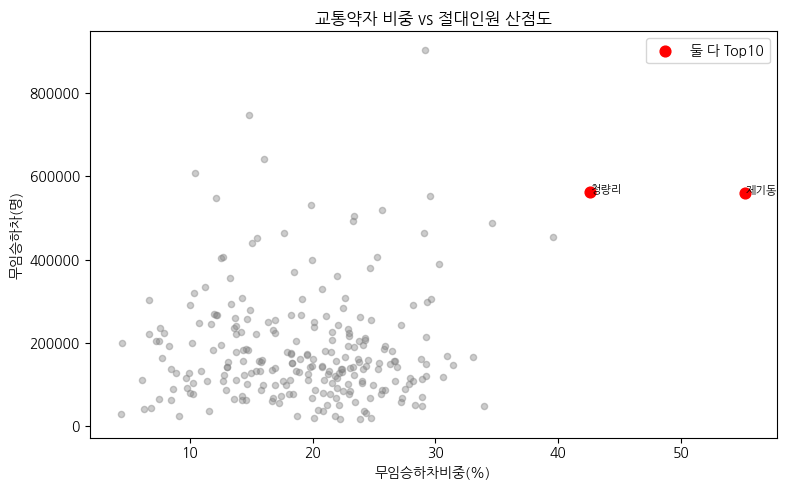

In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

# 전체 역 산점도 (배경)
ax.scatter(base_df['무임승하차비중'], base_df['무임승하차'], color='gray', alpha=0.4, s=20)

# 겹치는 역 강조 (overlap = set_ratio & set_abs)
overlap_df = base_df[base_df['지하철역'].isin(overlap)]
ax.scatter(overlap_df['무임승하차비중'], overlap_df['무임승하차'], color='red', s=60, label='둘 다 Top10')

# 역 이름 표시
for 역, x, y in zip(overlap_df['지하철역'], overlap_df['무임승하차비중'], overlap_df['무임승하차']):
    ax.annotate(역, (x, y), fontsize=8)

ax.set_xlabel('무임승하차비중(%)')
ax.set_ylabel('무임승하차(명)')
ax.set_title('교통약자 비중 vs 절대인원 산점도')
ax.legend()
plt.tight_layout()
plt.show()